In [29]:
import pandas as pd
import numpy as np
import os 
from pathlib import Path

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sn

from pandas.errors import EmptyDataError

In [30]:
models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges').glob("*"))
models.remove(models[0])
models

[PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-15dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-18dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_-5dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_0dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNNConstrained_5dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_s

In [31]:
#models.remove(models[0])
len(models)

32

In [32]:
#list(models[0].rglob("*.csv"))

In [33]:
# Get csvs of results for each model 

csv_str = 'metrics.csv'
#models = [attn_models[0], ctrl_models[0]]

dfs = []
for model in models:
    # get test csvs
    results_csvs = model.rglob("*.csv")
    
    for csv in results_csvs:
#         print(csv)
        try:
            df = pd.read_csv(csv)
        except EmptyDataError as e:
            print(csv, "empty csv")
#         except:
#             print("something went wrong")
            
        #print(model)

        df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
        test_parts = str(model).split("/")[-1].split("_")
        #print(test_parts)
        df['model'] = test_parts[0]
#       print(test_parts)
        df['snr_condition'] = test_parts[1]
        
        if (test_parts[0] == "AttnTrackingControl"):
            df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
            df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]
        
        dfs.append(df)
        
#         if 'Test' in path.as_posix()
results = pd.concat(dfs, axis=0, ignore_index=True)
results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
results.drop('epoch', axis=1, inplace=True)
results

/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges/AttnCNN_5dB_SNR/version_2/metrics.csv empty csv


,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,version,model,snr_condition,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion
0,1.0,1.0,0,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
1,1.0,1.0,1,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
2,0.0,1.0,2,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
3,1.0,0.0,3,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
4,1.0,0.0,4,0,AttnCNNConstrained,-10dB,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1537657,0.0,0.0,16588,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
1537658,0.0,0.0,16589,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
1537659,0.0,0.0,16590,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
1537660,0.0,0.0,16591,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN


In [34]:
#csv

In [35]:
# filter for most recent results 
version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
filtered_results = results[results.version == version_maxes]
filtered_results

,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,version,model,snr_condition,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion
38417,NaN,NaN,0,3,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0
38418,NaN,NaN,1,3,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0
38419,NaN,NaN,2,3,AttnCNNConstrained,-10dB,0.0,1.0,1.0,0.0
38420,NaN,NaN,3,3,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0
38421,NaN,NaN,4,3,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1537657,0.0,0.0,16588,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
1537658,0.0,0.0,16589,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
1537659,0.0,0.0,16590,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN
1537660,0.0,0.0,16591,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN


In [36]:
filtered_results['attended_accuracy'] = (filtered_results['ACC/test_fg_acc_step'] + filtered_results['ACC/test_bg_acc_step'])/2
filtered_results

/tmp/ipykernel_33137/756131252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['attended_accuracy'] = (filtered_results['ACC/test_fg_acc_step'] + filtered_results['ACC/test_bg_acc_step'])/2


,ACC/test_fg_acc_step,ACC/test_bg_acc_step,step,version,model,snr_condition,ACC/test_fg_acc,fg_confusion,ACC/test_bg_acc,bg_confusion,attended_accuracy
38417,NaN,NaN,0,3,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0,NaN
38418,NaN,NaN,1,3,AttnCNNConstrained,-10dB,1.0,0.0,1.0,0.0,NaN
38419,NaN,NaN,2,3,AttnCNNConstrained,-10dB,0.0,1.0,1.0,0.0,NaN
38420,NaN,NaN,3,3,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0,NaN
38421,NaN,NaN,4,3,AttnCNNConstrained,-10dB,1.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1537657,0.0,0.0,16588,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN,0.0
1537658,0.0,0.0,16589,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN,0.0
1537659,0.0,0.0,16590,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN,0.0
1537660,0.0,0.0,16591,3,AttnTrackingControl,clean,0.0,NaN,0.0,NaN,0.0


In [37]:
filtered_results['model'].replace('AttnCNN','unconstrained slope',inplace=True)
filtered_results['model'].replace('AttnCNNConstrained','constrained slope',inplace=True)
filtered_results['model'].replace('AttnTrackingControl','control',inplace=True)



/tmp/ipykernel_33137/3056990132.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['model'].replace('AttnCNN','unconstrained slope',inplace=True)
/tmp/ipykernel_33137/3056990132.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['model'].replace('AttnCNNConstrained','constrained slope',inplace=True)
/tmp/ipykernel_33137/3056990132.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_results['

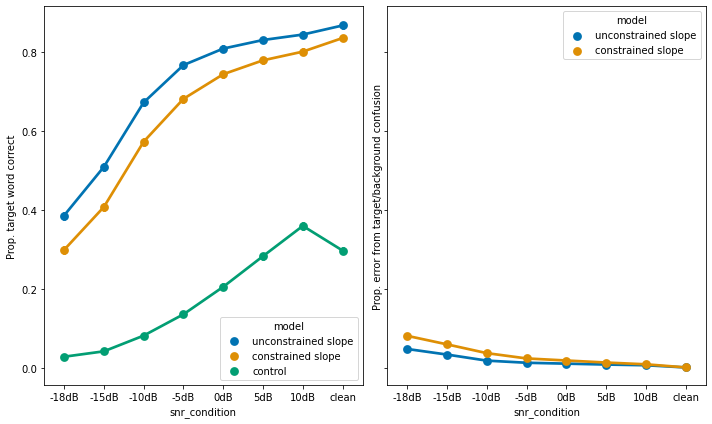

In [38]:
fig, axs = plt.subplots(1,2, sharey=True, figsize=(10,6))
axs = axs.ravel()

g = sn.pointplot(
    data=filtered_results, x='snr_condition',y='ACC/test_fg_acc',
    hue='model', hue_order=['unconstrained slope', 'constrained slope', "control"],
    ci=95, seed=1, ax=axs[0],
    palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
)


g1 = sn.pointplot(
    data=filtered_results, x='snr_condition',y='fg_confusion',
    hue='model', hue_order=['unconstrained slope', 'constrained slope'],
    ci=95, seed=1, ax=axs[1],
    palette='colorblind', order=['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']
)

axs[0].set_ylabel("Prop. target word correct")
axs[1].set_ylabel("Prop. error from target/background confusion")

plt.tight_layout()

#axs.set(xlabel="snr range", ylabel='proportion correct', title='snr check')
#g.set_xticklabels(['[5dB, 10dB]', '[-10dB, -5dB]', '0dB'])

In [39]:
test = filtered_results.groupby(['model', 'snr_condition']).mean()
test

ACC/test_fg_acc_step  ACC/test_bg_acc_step  \
model               snr_condition                                               
AttnCNNPosSlope     -10dB                           NaN                   NaN   
                    -15dB                           NaN                   NaN   
                    -18dB                           NaN                   NaN   
                    -5dB                            NaN                   NaN   
                    0dB                             NaN                   NaN   
                    10dB                            NaN                   NaN   
                    5dB                             NaN                   NaN   
                    clean                           NaN                   NaN   
constrained slope   -10dB                           NaN                   NaN   
                    -15dB                           NaN                   NaN   
                    -18dB                           NaN                   NaN   
                    -5dB                            NaN                   NaN   
                    0dB                             NaN                   NaN   
                    10dB                            NaN                   NaN   
                    5dB                             NaN                   NaN   
                    clean                           NaN                   NaN   
control             -10dB                      0.082441              0.364264   
                    -15dB                      0.042648              0.431834   
                    -18dB                      0.028967              0.459910   
                    -5dB                       0.136450              0.290209   
                    0dB                        0.206103              0.210802   
                    10dB                       0.360397              0.080359   
                    5dB                        0.283785              0.140435   
                    clean                      0.297897              0.006810   
unconstrained slope -10dB                           NaN                   NaN   
                    -15dB                           NaN                   NaN   
                    -18dB                           NaN                   NaN   
                    -5dB                            NaN                   NaN   
                    0dB                             NaN                   NaN   
                    10dB                            NaN                   NaN   
                    5dB                             NaN                   NaN   
                    clean                           NaN                   NaN   

                                          step  ACC/test_fg_acc  fg_confusion  \
model               snr_condition                                               
AttnCNNPosSlope     -10dB          8405.500000         0.559541      0.037116   
                    -15dB          8405.500000         0.403640      0.063229   
                    -18dB          8405.500000         0.295384      0.088389   
                    -5dB           8405.500000         0.672079      0.024744   
                    0dB            8405.500000         0.734297      0.018261   
                    10dB           8405.500000         0.803414      0.009458   
                    5dB            8405.500000         0.778075      0.013800   
                    clean          8405.500000         0.847906      0.001903   
constrained slope   -10dB          8405.500000         0.573816      0.038068   
                    -15dB          8405.500000         0.408399      0.060314   
                    -18dB          8405.500000         0.299667      0.081906   
                    -5dB           8405.500000         0.682310      0.024625   
                    0dB            8405.500000         0.744706      0.019391   
                    10dB           8405.500000         0.801927  

## Background Noise Check (1 Talker)

In [79]:
models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise').glob("*"))
#models.remove(models[0])
models

[PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-15dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-18dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-5dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_0dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_5dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCN

In [80]:
len(models)

32

In [81]:
# Get csvs of results for each model 

csv_str = 'metrics.csv'
#models = [attn_models[0], ctrl_models[0]]
problem_children = []
passable = []

dfs = []
for model in models:
    # get test csvs
    results_csvs = model.rglob("*.csv")
    max_version = ""
    relevant_csv = ""
    
    for csv in results_csvs:
        current_version = os.path.dirname(csv).split('/')[-1]
        #print(current_version)
        if max_version == "":
            max_version = current_version
            relevant_csv = csv
        elif max_version < current_version:
            max_version = current_version
            relevant_csv = csv
    
    #print(relevant_csv)
    
    try:
        df = pd.read_csv(relevant_csv)
    except EmptyDataError as e:
        print(relevant_csv, "empty csv")

    if (df.shape != (16812, 2)):
        print(relevant_csv, df.shape)
        problem_children.append(relevant_csv)
    else:
        passable.append(relevant_csv)
        
    df['version'] = max_version
    test_parts = str(model).split("/")[-1].split("_")
    #print(test_parts)
    df['model'] = test_parts[0]
#       print(test_parts)
    df['snr_condition'] = test_parts[1]

#         if (test_parts[0] == "AttnTrackingControl"):
#             df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
#             df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

    dfs.append(df)
        
#         if 'Test' in path.as_posix()
# results = pd.concat(dfs, axis=0, ignore_index=True)
# results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
# results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
# results.drop('epoch', axis=1, inplace=True)
print(len(problem_children))
print(len(passable))
len(dfs)

/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-10dB_SNR/version_4/metrics.csv (12611, 2)
/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-15dB_SNR/version_4/metrics.csv (10490, 2)
/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-18dB_SNR/version_4/metrics.csv empty csv
/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-18dB_SNR/version_4/metrics.csv (10490, 5)
/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_-5dB_SNR/version_4/metrics.csv (12562, 2)
/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnCNNConstrained_clean/version_4/metrics.csv (12654, 2)
/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise/AttnTrackingControl_clean/version_4/met

32

## MultiTalker Check

In [69]:
models = list(Path('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr').glob("*"))
#models.remove(models[0])
print(len(models))
models

128


[PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr/1_talker_AttnCNNConstrained_-10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr/1_talker_AttnCNNConstrained_-15dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr/1_talker_AttnCNNConstrained_-18dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr/1_talker_AttnCNNConstrained_-5dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr/1_talker_AttnCNNConstrained_0dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr/1_talker_AttnCNNConstrained_10dB_SNR'),
 PosixPath('/om2/user/jcruse/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr/1_talker_AttnCNNConstrained_5dB_SNR'),
 Posi

In [72]:
# Get csvs of results for each model 

csv_str = 'metrics.csv'
#models = [attn_models[0], ctrl_models[0]]
problem_children = []
passable = []

dfs = []
for model in models:
    # get test csvs
    results_csvs = model.rglob("*.csv")
    max_version = ""
    relevant_csv = ""
    
    for csv in results_csvs:
        current_version = os.path.dirname(csv).split('/')[-1]
        print(current_version)
        if max_version == "":
            max_version = current_version
            relevant_csv = csv
        elif max_version < current_version:
            max_version = current_version
            relevant_csv = csv
    
    #print(relevant_csv)
    
    try:
        df = pd.read_csv(relevant_csv)
    except EmptyDataError as e:
        print(relevant_csv, "empty csv")

    if (df.shape != (16812, 2)):
        print(relevant_csv, df.shape)
        problem_children.append(relevant_csv)
    else:
        passable.append(relevant_csv)
        
    df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
    test_parts = str(model).split("/")[-1].split("_")
    #print(test_parts)
    df['model'] = test_parts[0]
#       print(test_parts)
    df['snr_condition'] = test_parts[1]

#         if (test_parts[0] == "AttnTrackingControl"):
#             df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
#             df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

    dfs.append(df)
        
#         if 'Test' in path.as_posix()

print(len(problem_children))
print(len(passable))
print(len(dfs))
results = pd.concat(dfs, axis=0, ignore_index=True)
# results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
# results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
# results.drop('epoch', axis=1, inplace=True)
results

version_0
version_0
version_1
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_1
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_0
version_1
version_0
version_0
version_0
version_0
version_0


,ACC/test_fg_acc,step,version,model,snr_condition
0,1.0,0,0,1,talker
1,1.0,1,0,1,talker
2,1.0,2,0,1,talker
3,1.0,3,0,1,talker
4,1.0,4,0,1,talker
...,...,...,...,...,...
2151931,0.0,16807,0,4,talker
2151932,1.0,16808,0,4,talker
2151933,0.0,16809,0,4,talker
2151934,0.0,16810,0,4,talker
